In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import math

In [18]:
algos = ['baseline', 'hedging', 'random', 'linnos', 'flashnet', 'surrogate_dt', 'dt', 'fixed_lat_dt', 'padded_lat_dt', 'hierarchy', 'small_surrogate_dt', 'small_hierarchy_p95', 'small_hierarchy_p98', 'small_hierarchy_p99']
percentiles_characteristics = ['avg', 'p50.0', 'p80.0', 'p90.0', 'p95.0', 'p96.0', 'p97.0', 'p98.0', 'p99.0', 'p99.9', 'p99.99']

In [19]:
grouping_dirs = {}
grouping_dirs['data'] = "/mnt/heimdall-exp/Heimdall/integration/client-level/data"

## Examine the Stats

In [20]:
col_names = ['algo', 'grouping_dir', 'trace_dir'] + percentiles_characteristics
df = pd.DataFrame(columns = col_names)

for key, grouping_dir in grouping_dirs.items():
    trace_dirs_1 = [os.path.join(grouping_dir, dir) for dir in os.listdir(grouping_dir) if os.path.isdir(os.path.join(grouping_dir, dir))]
    trace_dirs_2 = []
    for trace_dir in trace_dirs_1:
        trace_dirs_2.extend([os.path.join(trace_dir, dir) for dir in os.listdir(trace_dir) if os.path.isdir(os.path.join(trace_dir, dir))])
    trace_dirs_3 = []
    for trace_dir in trace_dirs_2:
        trace_dirs_3.extend([os.path.join(trace_dir, dir) for dir in os.listdir(trace_dir) if os.path.isdir(os.path.join(trace_dir, dir))])
    trace_dirs_4 = []
    for trace_dir in trace_dirs_3:
        trace_dirs_4.extend([os.path.join(trace_dir, dir) for dir in os.listdir(trace_dir) if os.path.isdir(os.path.join(trace_dir, dir))])
    trace_dirs = trace_dirs_4

    for trace_dir in trace_dirs:
        for algo in algos:
            this_data = [algo, key, trace_dir]
            try:
                f = open(os.path.join(trace_dir, algo, "latency_characteristic.stats"), "r")
                latency_characteristic = f.readlines()
                for p in percentiles_characteristics:
                    for line in latency_characteristic:
                        if line.split(' = ')[0] == p:
                            this_data.append(float(line.split(' = ')[1].split(' us')[0]))
                df.loc[len(df)] = this_data
            except:
                print("CHAR", algo, trace_dir)

df

CHAR surrogate_dt /mnt/heimdall-exp/Heimdall/integration/client-level/data/alibaba.per_3mins.overall_p25.alibaba_9076.45/tencent.per_3mins.write_p100.2018-10-09-04.12/modified.rerate_0.50...modified.rerate_0.50/nvme14n1...nvme15n1
CHAR dt /mnt/heimdall-exp/Heimdall/integration/client-level/data/alibaba.per_3mins.overall_p25.alibaba_9076.45/tencent.per_3mins.write_p100.2018-10-09-04.12/modified.rerate_0.50...modified.rerate_0.50/nvme14n1...nvme15n1
CHAR fixed_lat_dt /mnt/heimdall-exp/Heimdall/integration/client-level/data/alibaba.per_3mins.overall_p25.alibaba_9076.45/tencent.per_3mins.write_p100.2018-10-09-04.12/modified.rerate_0.50...modified.rerate_0.50/nvme14n1...nvme15n1
CHAR padded_lat_dt /mnt/heimdall-exp/Heimdall/integration/client-level/data/alibaba.per_3mins.overall_p25.alibaba_9076.45/tencent.per_3mins.write_p100.2018-10-09-04.12/modified.rerate_0.50...modified.rerate_0.50/nvme14n1...nvme15n1
CHAR hierarchy /mnt/heimdall-exp/Heimdall/integration/client-level/data/alibaba.per_3

,algo,grouping_dir,trace_dir,avg,p50.0,p80.0,p90.0,p95.0,p96.0,p97.0,p98.0,p99.0,p99.9,p99.99
0,baseline,data,/mnt/heimdall-exp/Heimdall/integration/client-...,269.034722,124.0,432.0,626.0,785.0,833.0,896.0,997.0,1387.0,4607.021,6403.8063
1,hedging,data,/mnt/heimdall-exp/Heimdall/integration/client-...,258.005206,132.0,447.0,648.0,808.0,857.0,920.0,1025.0,1253.0,1389.000,1683.0000
2,random,data,/mnt/heimdall-exp/Heimdall/integration/client-...,207.805341,91.0,257.0,503.0,691.0,745.0,816.0,922.0,1250.0,4642.000,8057.2042
3,linnos,data,/mnt/heimdall-exp/Heimdall/integration/client-...,369.385808,218.0,554.0,748.0,909.0,962.0,1036.0,1178.0,2536.0,5165.042,9809.2042
4,flashnet,data,/mnt/heimdall-exp/Heimdall/integration/client-...,151.206212,100.0,151.0,248.0,441.0,498.0,568.0,673.0,843.0,3973.021,7160.6336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,padded_lat_dt,data,/mnt/heimdall-exp/Heimdall/integration/client-...,141.129039,101.0,199.0,340.0,472.0,506.0,551.0,614.0,731.0,1420.826,4681.8042
104,hierarchy,data,/mnt/heimdall-exp/Heimdall/integration/client-...,142.249938,105.0,197.0,325.0,463.0,496.0,538.0,598.0,704.0,1318.000,4195.9564
105,small_surrogate_dt,data,/mnt/heimdall-exp/Heimdall/integration/client-...,121.095979,79.0,178.0,308.0,445.0,478.0,520.0,577.0,674.0,1165.000,2721.8732
106,small_hierarchy_p95,data,/mnt/heimdall-exp/Heimdall/integration/client-...,139.819953,102.0,196.0,323.0,462.0,495.0,537.0,595.0,696.0,1195.826,2802.2826


In [21]:
collection = df.groupby(['algo'])[percentiles_characteristics].mean().reindex(algos)
# convert value to ms
collection_ms = collection / 1000
collection_ms

,avg,p50.0,p80.0,p90.0,p95.0,p96.0,p97.0,p98.0,p99.0,p99.9,p99.99
algo,,,,,,,,,,,
baseline,0.272041,0.174833,0.438250,0.623750,0.783833,0.838750,0.908917,1.016333,1.263333,3.157142,4.839740
hedging,0.269428,0.183667,0.441917,0.625583,0.786417,0.838417,0.907667,1.010583,1.173688,1.492681,1.927944
random,0.210470,0.110667,0.309583,0.524500,0.711917,0.770500,0.848000,0.965377,1.216333,3.101232,5.017769
linnos,0.214380,0.144917,0.296083,0.428667,0.594250,0.658750,0.739167,0.855583,1.150083,2.534582,4.886273
flashnet,0.162207,0.099000,0.209083,0.328417,0.512333,0.577167,0.659083,0.775500,1.012167,2.488838,4.714522
surrogate_dt,0.136985,0.083000,0.209167,0.337167,0.465333,0.503500,0.553500,0.626667,0.761833,1.652834,6.291406
dt,0.137561,0.083000,0.207833,0.338167,0.472833,0.512833,0.566000,0.642667,0.785368,1.540592,6.029345
fixed_lat_dt,0.147232,0.095167,0.216500,0.342333,0.475833,0.515333,0.567333,0.642833,0.784000,1.479317,4.003068
padded_lat_dt,0.148670,0.096500,0.216667,0.342000,0.475333,0.514833,0.567167,0.644167,0.791167,1.534831,5.291174


/tmp/ipykernel_482234/881877307.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(label, rotation=90)


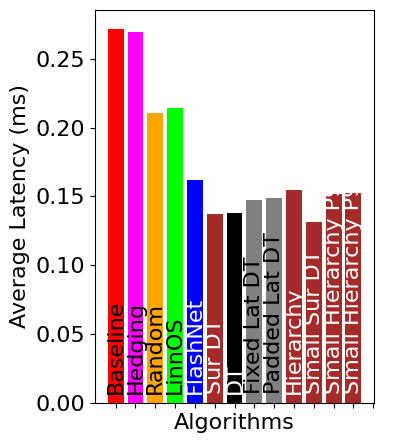

In [22]:
plt.rcParams.update({'font.size': 16})

algos = ['baseline', 'hedging', 'random', 'linnos', 'flashnet', 'surrogate_dt', 'dt', 'fixed_lat_dt', 'padded_lat_dt', 'hierarchy', 'small_surrogate_dt', 'small_hierarchy_p95', 'small_hierarchy_p98', 'small_hierarchy_p99']
label = ['Baseline', 'Hedging', 'Random', 'LinnOS', 'FlashNet', 'Sur DT', 'DT', 'Fixed Lat DT', 'Padded Lat DT', 'Hierarchy', 'Small Sur DT', 'Small Hierarchy P95', 'Small Hierarchy P98', 'Small Hierarchy P99']
font_colors = ['black', 'black', 'black', 'black', 'white', 'white', 'white', 'black', 'black', 'white', 'white', 'white', 'white', 'white']
colors = ['red', 'magenta', 'orange', 'lime', 'blue', 'brown', 'black', 'gray', 'gray', 'brown', 'brown', 'brown', 'brown', 'brown']

metric = "avg"

fig, ax = plt.subplots(figsize=(3.6, 5.1))
ax.bar(algos, collection_ms[metric], label=label, color=colors)
# ax.set_title('Latency at '+ metric +' (Light-Light)')
ax.set_ylabel('Average Latency (ms)')
# ax.set_ylim(0, 0.5)
# ax.set_yticklabels(["0", ".1", ".2", ".3", ".4", ".5"])
ax.set_xticklabels(label, rotation=90)
ax.set_xlabel('Algorithms')
ax.tick_params(axis='x', which='major', pad=-10)
for ticklabel, tickcolor in zip(fig.gca().get_xticklabels(), font_colors):
    ticklabel.set_color(tickcolor)
    ticklabel.set_horizontalalignment("center")
    ticklabel.set_verticalalignment("bottom")
# plt.text(-0.75, 0.5125, "(d) Light-Heavy", fontweight='bold')
# plt.text(4.72, 0.165, "et", rotation=90)
plt.savefig(os.path.join("eval-client-avg.eps"), dpi=200, bbox_inches='tight', format='eps')
plt.show()

['Baseline', 'Hedging', 'Random', 'LinnOS', 'FlashNet', 'Surrogate DT', 'DT', 'Fixed Lat DT', 'Padded Lat DT', 'Hierarchy', 'Small Sur DT', 'Small Hierarchy P95', 'Small Hierarchy P98', 'Small Hierarchy P99']


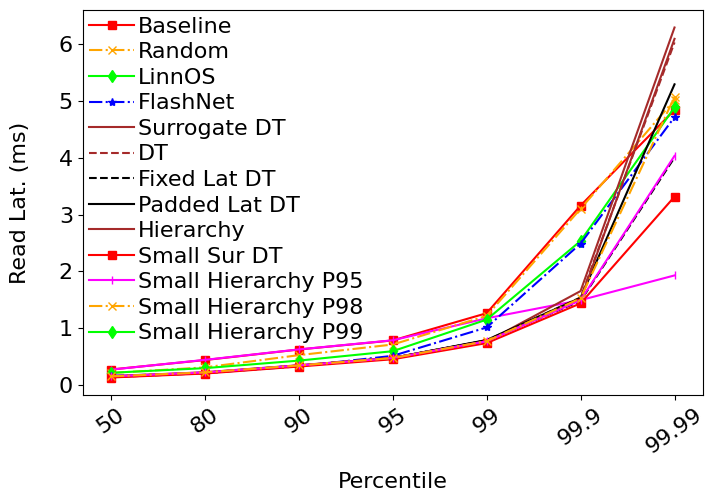

In [24]:
# Draw baseline vs flashnet line chart

algos = ['baseline', 'hedging', 'random', 'linnos', 'flashnet', 'surrogate_dt', 'dt', 'fixed_lat_dt', 'padded_lat_dt', 'hierarchy', 'small_surrogate_dt', 'small_hierarchy_p95', 'small_hierarchy_p98', 'small_hierarchy_p99']
line_legend = ['Baseline', 'Hedging', 'Random', 'LinnOS', 'FlashNet', 'Surrogate DT', 'DT', 'Fixed Lat DT', 'Padded Lat DT', 'Hierarchy', 'Small Sur DT', 'Small Hierarchy P95', 'Small Hierarchy P98', 'Small Hierarchy P99']
colors = ['red', 'magenta', 'orange', 'lime', 'blue', 'brown', 'brown', 'black', 'black', 'brown', 'red', 'magenta', 'orange', 'lime']
styles = ['s-', '|-', 'x-.', 'd-', '*-.', '-', '--', '--', '-', '-', 's-', '|-', 'x-.', 'd-']

x_labels = ["avg", "p80.0", "p90.0", "p95.0", "p99.0", "p99.9", "p99.99"]
x_ticks = ["50", "80", "90", "95", "99", "99.9", "99.99"]

fig, ax = plt.subplots(figsize=(8, 5))
for idx, algo in enumerate(algos):
    ax.plot(np.arange(len(x_labels)), collection_ms.loc[algo][x_labels].values, styles[idx], label=line_legend[idx], color=colors[idx], linewidth=1.5)

handles, labels = ax.get_legend_handles_labels()
print(labels)

ax.legend([handles[0], handles[2], handles[3], handles[4], handles[5], handles[6], handles[7], handles[8], handles[9], handles[10], handles[11], handles[12], handles[13]], [labels[0], labels[2], labels[3], labels[4], labels[5], labels[6], labels[7], labels[8], labels[9], labels[10], labels[11], labels[12], labels[13]], loc='upper left', frameon=False, labelspacing=0.25, columnspacing=0.5, borderpad=-0.2, handletextpad=0.2, handlelength=2)
ax.set_xticks(np.arange(len(x_ticks)), x_ticks)
ax.set_xticklabels(x_ticks, rotation=35, ha='center')
# add y label
# ax.set_ylim(0, 8)
ax.set_ylabel("Read Lat. (ms)")
ax.set_xlabel("Percentile")
ax.xaxis.set_label_coords(0.5, -0.2)
ax.yaxis.set_label_coords(-0.085, 0.5)
plt.savefig(os.path.join("eval-client-line.eps"), dpi=200, bbox_inches='tight', format='eps')
plt.show()